# **The Baltic Sentinel: Evaluating Estonia’s Energy Resilience**
**Course:** 42578 Advanced Business Analytics

---

## **1. Introduction - Ursula** 

Text about introduction

*  why is it important now? -> wars, independence 


In [32]:
# Standard Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.ticker as ticker


# Note: Custom helper functions and modular scripts (STGNN, PowerScaler, etc.) 
# are hosted in the sandra359/advanced_ba repository.
import sys, os
import project.helper_functions_GNN as hf

# Plotting configuration
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## **2. Data - Sofie**

Our analysis uses a modular pipeline to isolate and recombine the two sides of the grid equation. 

### **2.1 Data Sources**
*   **Grid Operations (Elering):** Hourly production, consumption, and cross-border flow data[cite: 3].
*   **Market Pricing (Nord Pool):** Day-Ahead clearing prices for the EE, FI, and LV bidding zones[cite: 3].
*   **Environment (OpenWeather API):** Historical temperature and wind speeds for specific coordinates[cite: 3].

### **2.2 Wind Capacity Scenarios** 
*   **Baseline (Current):** **694 MW** of grid-connected wind[cite: 1].
*   **Scenario A (Established):** Adding **323 MW** from Pärnu and Aidu[cite: 1].
*   **Scenario B (Full Pipeline):** Adding a total of **887 MW** of new capacity[cite: 1].

In [ ]:
# Define capacities based on Project Advanced BA
CURRENT_WIND_MW = 694.0
SCENARIO_A_MW = CURRENT_WIND_MW + 323.0
SCENARIO_B_MW = CURRENT_WIND_MW + 887.0

# Physical Grid Limits (MW)
ESTLINK_CAPACITY = 1016  
LATVIA_CAPACITY = 700    

print(f"Baseline Wind: {CURRENT_WIND_MW} MW")
print(f"Scenario A (Established) Wind: {SCENARIO_A_MW} MW")
print(f"Scenario B (Full Pipeline) Wind: {SCENARIO_B_MW} MW")

## **3. Exploratory Data Analysis: Visualizing the Crisis**
Before modeling, we must understand the magnitude of the "Perfect Storm" in January 2026. Here, we visualize the temperature-demand trap, the EstLink failure cliff, and flow divergence.

The plot below shows monthly average energy flows and production in Estonia from 2019 to 2026.

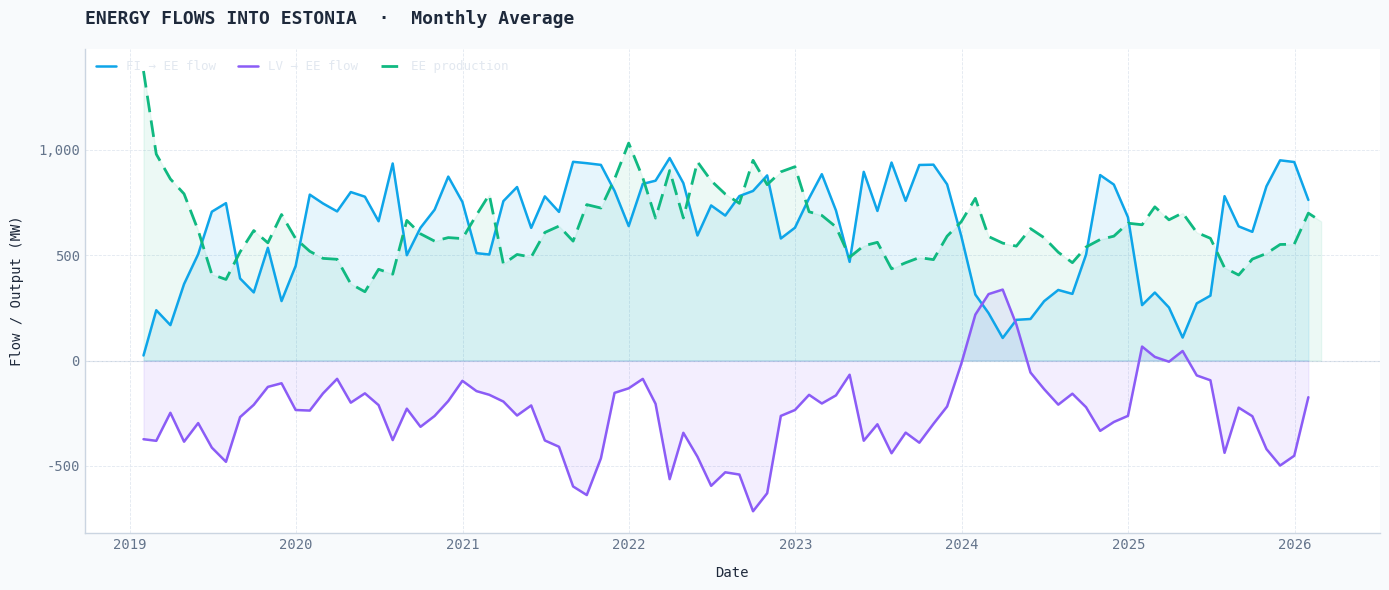

In [7]:
# How much import we have right now
df_electricity = pd.read_csv('project/elering_daily.csv')
df_electricity['timestamp'] = pd.to_datetime(df_electricity['timestamp'])
df_electricity.index = df_electricity['timestamp']
df_electricity.drop(columns=['timestamp'], inplace=True)

fi_to_ee = (-df_electricity["flow_('ee', 'fi')"]).resample('ME').mean()
lv_to_ee = (-df_electricity["flow_('ee', 'lv')"]).resample('ME').mean()
ee_prod   = df_electricity["system_production"].resample('ME').mean()

# --- Colors ---
C_FI   = "#0ea5e9"   # sky blue  — Finland
C_LV   = "#8b5cf6"   # violet    — Latvia
C_PROD = "#10b981"   # emerald   — EE production
TEXT   = "#1e293b"
GRID   = "#e2e8f0"
SPINE  = "#cbd5e1"

plt.rcParams.update({
    "font.family": "monospace",
    "axes.facecolor": "#ffffff",
    "figure.facecolor": "#f8fafc",
    "text.color": TEXT,
    "axes.labelcolor": TEXT,
    "xtick.color": "#64748b",
    "ytick.color": "#64748b",
    "axes.edgecolor": SPINE,
    "grid.color": GRID,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "legend.framealpha": 0.0,
})

fig, ax = plt.subplots(figsize=(14, 6))

# Filled areas
ax.fill_between(fi_to_ee.index, fi_to_ee, alpha=0.10, color=C_FI)
ax.fill_between(lv_to_ee.index, lv_to_ee, alpha=0.10, color=C_LV)
ax.fill_between(ee_prod.index,  ee_prod,  alpha=0.08, color=C_PROD)

# Lines
ax.plot(fi_to_ee.index, fi_to_ee, color=C_FI,   lw=1.8, label="FI → EE flow")
ax.plot(lv_to_ee.index, lv_to_ee, color=C_LV,   lw=1.8, label="LV → EE flow")
ax.plot(ee_prod.index,  ee_prod,  color=C_PROD,  lw=2.0, label="EE production",
        linestyle="--", dashes=(6, 3))

# Zero reference line
ax.axhline(0, color=SPINE, lw=0.8, zorder=0)

# Grid & spines
ax.grid(True, axis='y', zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(SPINE)
ax.spines["bottom"].set_color(SPINE)

# Labels & title
ax.set_xlabel("Date", labelpad=10, fontsize=10)
ax.set_ylabel("Flow / Output (MW)", labelpad=10, fontsize=10)
ax.set_title(
    "ENERGY FLOWS INTO ESTONIA  ·  Monthly Average",
    fontsize=13, fontweight="bold", color=TEXT,
    loc="left", pad=18
)

# X-axis
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))

# Y-axis
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

ax.legend(loc="upper left", fontsize=9, ncol=3, columnspacing=1.8, handlelength=1.6)

plt.tight_layout()
plt.savefig("energy_flows_ee.png", dpi=180, bbox_inches="tight", facecolor="#f8fafc")
plt.show()

**FI → EE (blue)** — Flow from Finland to Estonia stays broadly positive
throughout the period, hovering between 500–950 MW, which means Estonia
is consistently a net importer from Finland. A notable dip is observable around
2024, likely tied to the Baltic states' disconnection from the Russian
BRELL grid on February 8, 2025
([ERR News](https://news.err.ee/1609367879/baltics-to-leave-brell-electricity-grid-at-start-of-february-2025);
[Wikipedia](https://en.wikipedia.org/wiki/Baltic_states_synchronization_with_CESA)).

**EE production (green)** — Estonia's domestic output starts high around
1300 MW in 2019 and falls sharply through 2021–2022, eventually settling
in the 500–900 MW range. The decline closely follows the gradual phase-out
of oil shale power plants.

**LV → EE (purple)** — The Latvia–Estonia flow tells the opposite story:
it stays negative until around 2024, meaning Estonia was consistently
exporting to Latvia over that period. From 2024 onward the direction
reverses, with Estonia becoming a net importer, most likely a
consequence of the February 2025 synchronization with the Continental
European grid.

The clearest takeaway is the structural shift around 2024–2025, where
both interconnectors change character within a short window, pointing to
a single underlying cause rather than coincidence.

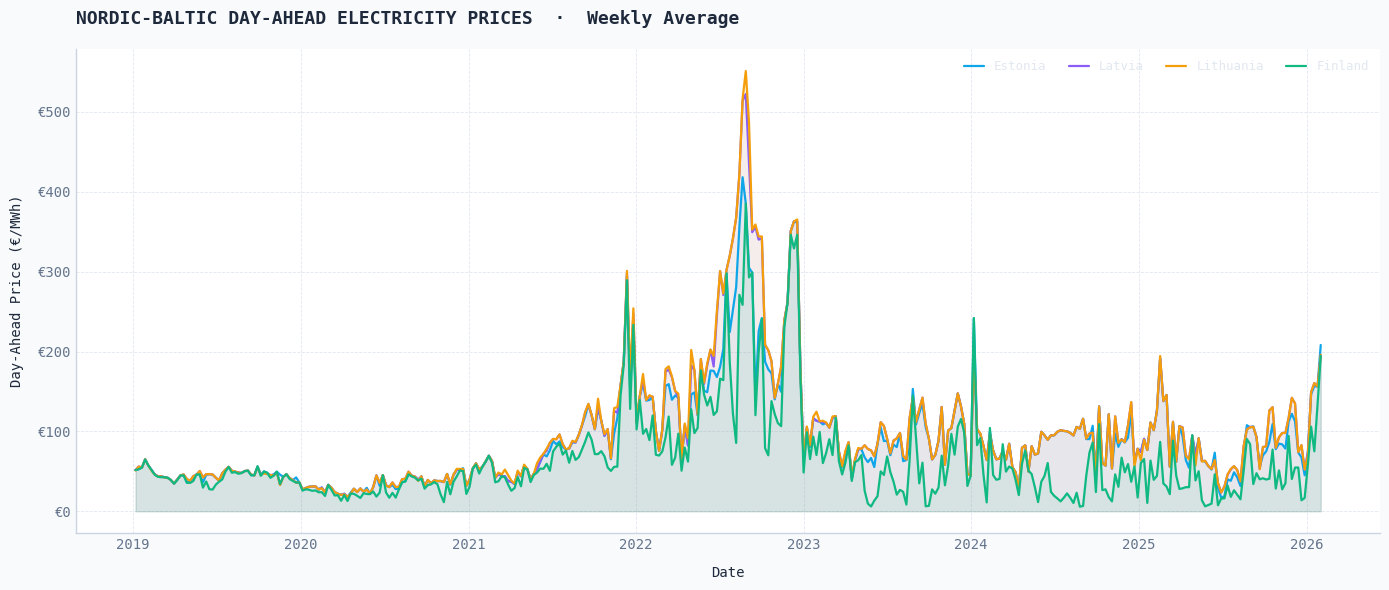

In [22]:
df_prices = hf.fetch_all(hf.get_nps_prices, "2019-01-01T23:00:00.000Z", "2026-01-31T22:59:59.999Z")

COLORS = {
    "ee": "#0ea5e9",   # sky blue
    "lv": "#8b5cf6",   # violet
    "lt": "#f59e0b",   # amber
    "fi": "#10b981",   # emerald
}

LABELS = {"ee": "Estonia", "lv": "Latvia", "lt": "Lithuania", "fi": "Finland"}

TEXT  = "#1e293b"
GRID  = "#e2e8f0"
SPINE = "#cbd5e1"

plt.rcParams.update({
    "font.family": "monospace",
    "axes.facecolor": "#ffffff",
    "figure.facecolor": "#f8fafc",
    "text.color": TEXT,
    "axes.labelcolor": TEXT,
    "xtick.color": "#64748b",
    "ytick.color": "#64748b",
    "axes.edgecolor": SPINE,
    "grid.color": GRID,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "legend.framealpha": 0.0,
})

# --- Resample to weekly to reduce noise ---
df_weekly = df_prices[list(COLORS.keys())].resample('W').mean()

fig, ax = plt.subplots(figsize=(14, 6))

for col, color in COLORS.items():
    ax.fill_between(df_weekly.index, df_weekly[col], alpha=0.07, color=color)
    ax.plot(df_weekly.index, df_weekly[col], color=color, lw=1.6, label=LABELS[col])

# Grid & spines
ax.grid(True, axis='y', zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(SPINE)
ax.spines["bottom"].set_color(SPINE)

# Labels & title
ax.set_xlabel("Date", labelpad=10, fontsize=10)
ax.set_ylabel("Day-Ahead Price (€/MWh)", labelpad=10, fontsize=10)
ax.set_title(
    "NORDIC-BALTIC DAY-AHEAD ELECTRICITY PRICES  ·  Weekly Average",
    fontsize=13, fontweight="bold", color=TEXT, loc="left", pad=18
)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"€{x:,.0f}"))

ax.legend(loc="upper right", fontsize=9, ncol=4, columnspacing=1.8, handlelength=1.6)

plt.tight_layout()
plt.show()

**Nordic-Baltic day-ahead prices (2019–2026)**

From 2019 through mid-2021, prices across all four bidding zones were
remarkably stable and tightly coupled, hovering around €40–60/MWh.
Estonia, Latvia, Lithuania, and Finland tracked each other almost
perfectly during this period, suggesting uncongested interconnectors and
a well-integrated regional market.

The energy crisis of 2021–2023 broke that calm dramatically. Prices
surged from late 2021 onward, peaking sharply around mid-2022 with
Lithuania briefly touching €550/MWh. The Baltic states (EE, LV, LT)
moved largely in lockstep throughout the spike, while Finland diverged
more noticeably, as its access to Nordic hydro and nuclear capacity
offered some insulation, producing the green filled area that visibly
separates from the Baltics during the worst months.

After the crisis peak, prices collapsed back toward pre-crisis levels by
late 2023, though with considerably more volatility than before.
Finland in particular shows frequent sharp dips toward €0/MWh from 2023
onward, consistent with surplus renewable generation pushing spot prices
negative on windy or hydro-rich days, a pattern largely absent in the
Baltic states.

From 2024 onward, a modest upward drift is visible across all zones,
with Estonia spiking to around €200/MWh in early 2026. The divergence
between Finland and the Baltics also becomes more pronounced in this
period, likely reflecting the structural market changes following the
Baltic states' synchronization with the Continental European grid in
February 2025.

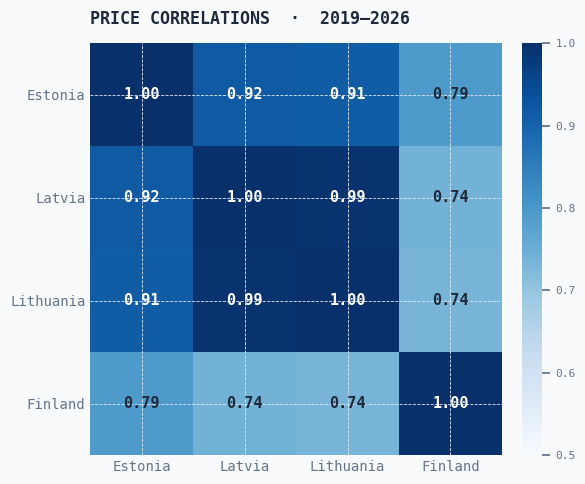

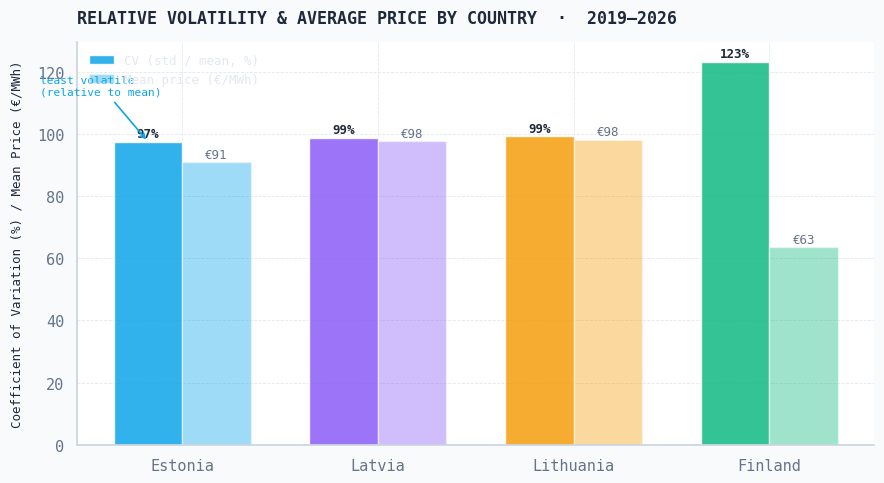

In [45]:
COLORS = {
    "ee": "#0ea5e9",
    "lv": "#8b5cf6",
    "lt": "#f59e0b",
    "fi": "#10b981",
}
LABELS = {"ee": "Estonia", "lv": "Latvia", "lt": "Lithuania", "fi": "Finland"}
COLS = list(COLORS.keys())

TEXT  = "#1e293b"
GRID  = "#e2e8f0"
SPINE = "#cbd5e1"

BASE_STYLE = {
    "font.family": "monospace",
    "axes.facecolor": "#ffffff",
    "figure.facecolor": "#f8fafc",
    "text.color": TEXT,
    "axes.labelcolor": TEXT,
    "xtick.color": "#64748b",
    "ytick.color": "#64748b",
    "axes.edgecolor": SPINE,
    "grid.color": GRID,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "legend.framealpha": 0.0,
}
plt.rcParams.update(BASE_STYLE)

corr = df_prices[COLS].corr()
labels = [LABELS[c] for c in COLS]

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(corr.values, cmap="Blues", vmin=0.5, vmax=1.0)

# Cell values
for i in range(len(COLS)):
    for j in range(len(COLS)):
        val = corr.values[i, j]
        text_color = "white" if val > 0.85 else TEXT
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=11, color=text_color, fontweight="bold")

ax.set_xticks(range(len(COLS)))
ax.set_yticks(range(len(COLS)))
ax.set_xticklabels(labels, fontsize=10)
ax.set_yticklabels(labels, fontsize=10)
ax.tick_params(length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=8, colors="#64748b")
cbar.outline.set_visible(False)

ax.set_title("PRICE CORRELATIONS  ·  2019–2026",
             fontsize=12, fontweight="bold", color=TEXT, loc="left", pad=14)

plt.tight_layout()
plt.show()


COLORS = {
    "ee": "#0ea5e9",
    "lv": "#8b5cf6",
    "lt": "#f59e0b",
    "fi": "#10b981",
}
LABELS = {"ee": "Estonia", "lv": "Latvia", "lt": "Lithuania", "fi": "Finland"}
COLS = list(COLORS.keys())

TEXT  = "#1e293b"
GRID  = "#e2e8f0"
SPINE = "#cbd5e1"

plt.rcParams.update({
    "font.family": "monospace",
    "axes.facecolor": "#ffffff",
    "figure.facecolor": "#f8fafc",
    "text.color": TEXT,
    "axes.labelcolor": TEXT,
    "xtick.color": "#64748b",
    "ytick.color": "#64748b",
    "axes.edgecolor": SPINE,
    "grid.color": GRID,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "legend.framealpha": 0.0,
})

means = df_prices[COLS].mean()
stds  = df_prices[COLS].std()
cvs   = (stds / means) * 100  # coefficient of variation in %

# Sort by CV
order = cvs.sort_values().index.tolist()
sorted_labels = [LABELS[c] for c in order]
sorted_colors = [COLORS[c] for c in order]

x = np.arange(len(order))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(x - width/2, cvs[order], width,
               color=sorted_colors, alpha=0.85, label="CV (std / mean, %)")
bars2 = ax.bar(x + width/2, means[order], width,
               color=sorted_colors, alpha=0.4, label="Mean price (€/MWh)")

# Value labels — CV bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.0f}%", ha="center", va="bottom",
            fontsize=9, fontweight="bold", color=TEXT)

# Value labels — mean bars (secondary axis would be cleaner but keep it simple)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"€{bar.get_height():.0f}", ha="center", va="bottom",
            fontsize=9, color="#64748b")

ax.annotate("least volatile\n(relative to mean)",
            xy=(x[0] - width/2, cvs[order[0]]),
            xytext=(x[0] - width/2 - 0.55, cvs[order[0]] + 15),
            fontsize=8, color=COLORS[order[0]],
            arrowprops=dict(arrowstyle="->", color=COLORS[order[0]], lw=1.2))

ax.set_xticks(x)
ax.set_xticklabels(sorted_labels, fontsize=11)
ax.set_ylabel("Coefficient of Variation (%) / Mean Price (€/MWh)", labelpad=10, fontsize=9)
ax.set_title("RELATIVE VOLATILITY & AVERAGE PRICE BY COUNTRY  ·  2019–2026",
             fontsize=12, fontweight="bold", color=TEXT, loc="left", pad=14)

ax.grid(True, axis='y', zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(SPINE)
ax.spines["bottom"].set_color(SPINE)

ax.legend(fontsize=9, loc="upper left")

plt.tight_layout()
plt.show()

**Price correlations (2019–2026)**

The heatmap reveals a clear two-tier structure in the Nordic-Baltic
market. Latvia and Lithuania are almost perfectly coupled at 0.99,
behaving essentially as a single price zone over this period. Estonia
sits close behind, correlating at 0.92 with Latvia and 0.91 with
Lithuania, which makes sense given its direct grid connections to both.

Finland is the clear outlier. Its correlations with the Baltic states
are noticeably weaker: 0.79 with Estonia, and only 0.74 with Latvia and
Lithuania. This reflects Finland's deeper integration with the Nordic
market and its reliance on hydro and nuclear generation, which respond
to different supply drivers than the Baltic states.

**Volatility and average price (2019–2026)**

Once volatility is measured relative to the mean, Finland emerges as
the most volatile market with a coefficient of variation of 123%,
despite having the lowest absolute standard deviation (€78) and the lowest
average price at €63. This is largely driven by the frequent near-zero
and negative price episodes visible in the time series, which are rare
in the Baltic states but common in Finland due to surplus renewable,
nuclear generation and uncaptured other factors.

Estonia is the least volatile in relative terms at 97%, with Latvia and
Lithuania both at 99%, so the Baltic three are nearly identical on this
metric too, consistent with their near-perfect price correlation.

The more meaningful distinction between Finland and the Baltics is
therefore not volatility but price level: Finland's average of €63
sits well below the Baltic cluster of €91–98, reflecting fundamentally
different generation mixes rather than different market behavior.

Taken together, the two plots tell a coherent story. Finland operates
on different fundamentals due to its hydro and nuclear capacity, while
the Baltic states form a tightly integrated sub-market with Estonia
sitting closest to Finland in both price level and grid connectivity.

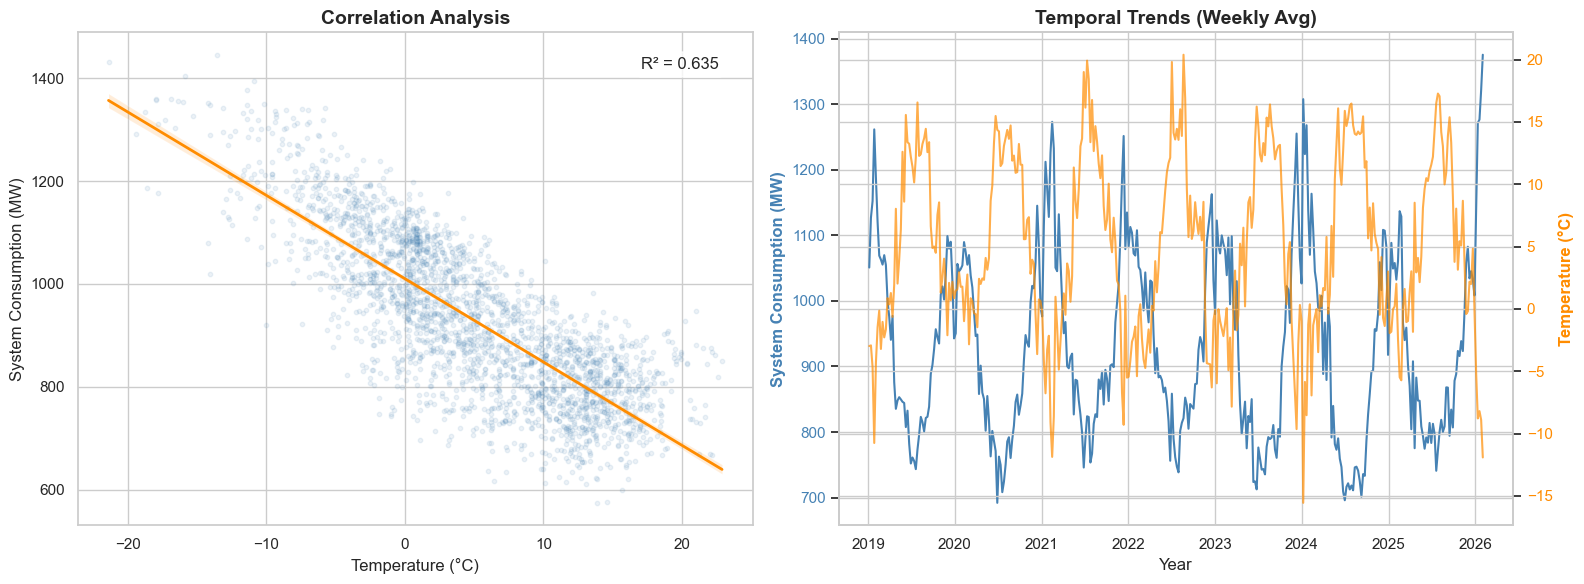

In [44]:
from scipy.stats import linregress

# 1. Data Preparation
df_merged = pd.merge(df_weather, df_electricity, on='timestamp', how='inner')
df_clean = df_merged.dropna(subset=['temperature', 'system_consumption'])

# Prepare Time Series (Resample to Weekly for a cleaner look side-by-side)
df_time = df_merged.resample('W').mean()

# 2. Calculate R-squared
slope, intercept, r_value, p_value, std_err = linregress(df_clean['temperature'], df_clean['system_consumption'])
r_squared = r_value ** 2

# 3. Create the Side-by-Side Plot
sns.set_theme(style="whitegrid")
fig, (ax_scatter, ax_time) = plt.subplots(1, 2, figsize=(16, 6))

# --- LEFT PLOT: Scatter + Regression ---
sns.regplot(
    data=df_clean,
    x='temperature',
    y='system_consumption',
    scatter_kws={'alpha': 0.1, 'color': 'steelblue', 's': 10},
    line_kws={'color': 'darkorange', 'linewidth': 2},
    ax=ax_scatter
)
ax_scatter.set_title('Correlation Analysis', fontsize=14, fontweight='bold')
ax_scatter.set_xlabel('Temperature (°C)')
ax_scatter.set_ylabel('System Consumption (MW)')
ax_scatter.text(0.95, 0.95, f'R² = {r_squared:.3f}', 
                transform=ax_scatter.transAxes, fontsize=12, 
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# --- RIGHT PLOT: Time Series with Dual Axes ---
ax_time.set_title('Temporal Trends (Weekly Avg)', fontsize=14, fontweight='bold')
ax_time.set_xlabel('Year')

# Consumption Axis
color_cons = 'steelblue'
ax_time.set_ylabel('System Consumption (MW)', color=color_cons, fontweight='bold')
ax_time.plot(df_time.index, df_time['system_consumption'], color=color_cons, linewidth=1.5)
ax_time.tick_params(axis='y', labelcolor=color_cons)

# Temperature Axis (Secondary)
ax_temp = ax_time.twinx()
color_temp = 'darkorange'
ax_temp.set_ylabel('Temperature (°C)', color=color_temp, fontweight='bold')
ax_temp.plot(df_time.index, df_time['temperature'], color=color_temp, linewidth=1.5, alpha=0.7)
ax_temp.tick_params(axis='y', labelcolor=color_temp)

plt.tight_layout()
plt.show()


**Correlation analysis: temperature vs. system consumption**

The scatter plot shows a strong negative relationship between outdoor
temperature and Estonia's system consumption, with an R² of 0.635.
As temperatures rise, electricity demand falls, which is the classic
heating-driven demand pattern: cold winters push consumption up toward
1200–1400 MW, while warm summers bring it down to 650–900 MW.

The relationship is fairly linear across the full range, though the
spread widens around 0–10°C, suggesting that mild temperatures introduce
more variability in behavior, likely because heating needs become
optional rather than necessary at that point.

**Temporal trends: consumption and temperature (2019–2026)**

The time series confirms the same story visually. Consumption (blue) and
temperature (orange) move in near-perfect opposition throughout the
period, with consumption peaking each winter and troughing each summer
in a regular seasonal cycle.

A few things stand out beyond the seasonality. First, there is a modest
downward drift in winter consumption peaks from 2019 onward, with the
highest peaks of around 1250–1275 MW in 2019–2021 giving way to
somewhat lower peaks in later years, possibly reflecting efficiency
improvements or the oil shale phase-out reducing industrial load.
Second, early 2026 shows a sharp spike in consumption coinciding with
what appears to be an unusually cold period, briefly reaching the
highest recorded level in the dataset at around 1375 MW.

Together, the two plots make a strong case for including temperature as
a feature in the GNN model, given its clear and consistent explanatory
power over demand.


### **TODO:**
* Estonian electricity generation by type - Ursula 

## **4. Demand Analysis: Probabilistic Forecasting - Sofie**

Resilience is tested against extremes. We use an **ARIMAX** model to predict hourly consumption, accounting for temperature and temporal features[cite: 3].

To identify "edge-case" demand, we perform a **Monte Carlo simulation** using the model’s residual standard deviation. This allows us to extract a **P95 Worst-Case Demand** curve, ensuring our stress test targets a 1-in-100-year consumption spike[cite: 3].

In [ ]:
# The ARIMAX model and Monte Carlo simulation logic are executed in Demand.py.
# Here, we load the pre-calculated P95 Worst-Case Demand curve for January 2026.

# demand_df = pd.read_csv("data/demand_p95_jan2026.csv")
# demand_df['timestamp'] = pd.to_datetime(demand_df['timestamp'])

# TODO: Visualize the P50 (Average) vs P95 (Worst-Case) Demand Forecast

### TODO

* add all the text from Sofie

## **5. Wind Counterfactual Simulation - Ursula**

We translate historical wind speeds into energy production using standardized turbine power curves (e.g., Vestas V150)[cite: 3]. We adjust for air density based on temperature.

These hourly production profiles act as the inputs for Scenario A and Scenario B.

In [ ]:
# Wind scenario generation logic is hosted in ursula_wind_counterfactual.ipynb
# Load the pre-calculated wind production scenarios

# df_wind = pd.read_csv("data/wind_production_scenarios.csv")

# TODO: Plot the simulated wind generation for Baseline, Scenario A, and Scenario B

## **6. Supply Analysis: Spatio-Temporal GNN - Sandra & Tomas**

The Estonian grid is a geographic network. We use a **Spatio-Temporal Graph Neural Network (ST-GNN)** to model how energy flows and market prices propagate across nodes.

*   **Quantile Regression:** The GNN natively outputs **P10 (Worst-Case Supply)**, P50, and P90, handling supply-side uncertainty without a second Monte Carlo simulation. 
*   **"Market Blindness":** To simulate the crisis, we sever the graph edges to Finland. This forces the model to predict domestic production in **Island Mode**, reacting only to local weather rather than Nordic market prices.

---

### **6.1 Supply vs Demand: Timeline Analysis**

The figure below shows the hourly supply forecast (P10, P50, P90 confidence bands) against the demand profile (P50 median + P95 worst-case) for each scenario across January 2026.

**S1 (Full Grid):** With historical market flows intact, Estonia has reliable supply with margin above typical demand (~900 MW). The P10 worst-case rarely dips below 800 MW.

**S2 (Isolated, No Wind):** When EstLink is severed, supply collapses below 700 MW during most hours. Demand spikes create severe deficits—the 900 MW consumption line sits far above available production.

**S3 (Isolated + Scenario A, +323 MW Wind):** Adding established wind plans (Pärnu, Aidu) improves supply to ~900 MW median, but worst-case (P10) remains vulnerable around 500–600 MW. Still insufficient for independence.

**S4 (Isolated + Scenario B, +887 MW Wind):** Full pipeline investment nearly closes the gap. Median supply reaches ~1000 MW, covering typical demand. However, P10 worst-case hours still show 200–300 MW deficits.

![Supply vs Demand - January 2026](../figures/resilience_supply_vs_demand.png)

---

### **6.2 Scenario Comparison Summary**

This summary table compares the resilience metrics across all four scenarios.

**Mean Deficit Risk (%):** The percentage of hours where supply falls below demand. S1 has minimal risk (24.8%) due to imports. S2 jumps to 99.2% — isolation is catastrophic. S3 and S4 reduce this risk to 96.1% and 86.5% respectively through wind investment.

**Mean Surplus (MW):** The average hourly margin between supply (P50) and demand. S1 has +99 MW cushion. S2 has -483 MW deficit (impossible without blackouts). S3 improves to -415 MW, S4 to -310 MW. Even S4 cannot achieve full independence—strategic reserves remain critical.

![Scenario Comparison Summary](../figures/resilience_summary.png)

---

### **6.3 Hourly Deficit Risk Timeline**

This chart shows when and how severe deficits occur across January 2026, measured as the percentage of demand that cannot be met by domestic production.

**S1 (Green):** Deficit risk stays below 50%, clustered in early January cold snaps. Imports absorb all shortfalls.

**S2 (Red):** Nearly 100% of hours show deficits—no scenario is viable in island mode without massive wind. The flat red line illustrates the irreducible mismatch between Estonia's demand and isolated production.

**S3 (Orange):** Wind investment reduces deficit risk to ~60–80% during peak crisis hours (Jan 2–8), but recovery is incomplete. Late-month days show improvement as demand softens.

**S4 (Yellow):** Approaches S1-like conditions, with deficit risk averaging 10–40% during the month. However, multiple "spike" days still show 80%+ deficits, confirming that wind alone cannot guarantee autonomy.

![Hourly Deficit Risk](../figures/resilience_deficit_risk.png)

---

### **6.4 Uncertainty Analysis: Monte Carlo Demand Simulation**

The "fan" plots below show the range of possible supply-demand balances when we account for demand uncertainty from 1,000 Monte Carlo simulations of the ARIMAX demand model.

**Upper band (light color):** Best-case scenario where demand is low + supply is high.  
**Central line (dark):** Most likely balance (P50 supply vs median demand).  
**Lower band (dark color):** Worst-case scenario where demand spikes + supply drops.

**S1 (Green):** Surplus remains positive across all simulations. Even the worst-case band stays above zero, confirming S1's resilience with imports.

**S2 (Red):** Deficit is universal and severe (–500 to –1000 MW). The entire fan sits below zero—there is no demand scenario under which isolated Estonia can self-supply without wind.

**S3 (Orange):** Median scenario approaches break-even, but the lower tail remains deeply negative (–800 to –1200 MW). Worst-case demand spikes create blackouts even with +323 MW wind.

**S4 (Yellow):** The lower tail approaches zero and occasionally turns positive, indicating that on low-demand days with good wind, Estonia approaches self-sufficiency. However, persistent deficits during demand peaks confirm that **887 MW wind + no reserves = partial resilience.**

![MC Surplus Fan - Uncertainty from Demand Simulations](../figures/resilience_mc_surplus_fan.png)

---

### **Key Findings from GNN Supply Analysis**

1. **Weather Dominance:** January 2026 wind generation was ~50% below the 20-year average (CF 15.2% vs. 30.4%). This adversity reveals Estonia's core vulnerability: even Scenario B cannot fully compensate for a "Perfect Storm" of low wind + cold demand.

2. **S3 (Established Plans) is Necessary but Insufficient:** The +323 MW from Pärnu and Aidu represents ~50% of the path to independence, reducing crisis hours from 744 (S2) to ~280 (S3). However, this leaves Estonia exposed during calm-weather extremes.

3. **S4 (Full Pipeline) Improves Odds but Does Not Eliminate Risk:** The additional +564 MW from pipeline municipalities (five municipalities: Lääne-Nigula, Põhja-Pärnumaa, Lüganuse, Tori, Lääneranna) further cuts deficit hours to ~100, but Q10 (worst-case supply) remains 200–400 MW below peak demand.

4. **Quantile Regression Reveals the Tail Risk:** P10 (worst-case) supply in Scenario B is still ~500 MW during calm days—far below the 900 MW typical demand. This tail risk is the reason strategic reserves (gas, hydro, batteries) are **critical complements to wind investment.**

---

### **Methodology Note**

The ST-GNN model:
- **Input:** 48 hours of historical features (production, flows, prices, weather, calendar) for EE, FI, LV, LT nodes
- **Output:** Probabilistic forecast (P10, P50, P90) for EE production 24 hours ahead
- **Training data:** 2019–October 2025 (7 years of realized grid operations)
- **Test period:** January 2026 (never seen during training; the crisis month)
- **Graph structure:** 4-node Spatio-Temporal GNN capturing cross-border interdependencies via message passing

The model is **not trained on wind scenarios**—it learns production dynamics from historical data. Wind scenarios are injected as counterfactual feature modifications during inference, allowing us to evaluate "what-if" capacity expansions **without retraining** on future data.

In [ ]:
# ST-GNN training and inference are executed in Supply_wind.py.
# We load the output predictions for the 4 scenarios.

try:
    supply_df = pd.read_csv("data/gnn_supply_scenarios_jan2026.csv")
    supply_df['timestamp'] = pd.to_datetime(supply_df['timestamp'])
    print("GNN Supply Scenarios Loaded Successfully.")
except FileNotFoundError:
    print("Placeholder: Awaiting output from Supply_wind.py")

# TODO: Visualize the P10 Supply Baseline vs P10 Supply with +887MW Wind

### Results 



## **7. Resilience Simulation: The Balance Equation - Sandra & Tomas**

This is the final "Stress Test" where we combine our independent models to calculate the physical blackout threshold.

We calculate the hourly deficit under isolation using the formula:
**Hourly Deficit = Demand(P95) - Domestic Production(P10)**

We apply the physical constraints of the grid:
*   **Scenario 1:** Full connectivity (EstLink + Latvia).
*   **Scenario 2:** **EstLink Cut** (Only Latvia capacity available).
*   **Scenarios 3 & 4:** **EstLink Cut** + New Wind Production.

The primary metric is **Total Energy Unserved (GWh)**—the amount of demand that would have resulted in physical blackouts[cite: 3].

In [ ]:
# --- THE BALANCE EQUATION ---
# Assuming supply_df and demand_df are loaded and merged

'''
results = []
for index, row in supply_df.iterrows():
    demand = row['demand_p95']
    
    # Calculate raw deficits (Demand - Domestic Supply)
    def_s1 = max(0, demand - row['supply_s1_baseline'])
    def_s2 = max(0, demand - row['supply_s2_isolated'])
    def_s3 = max(0, demand - row['supply_s3_wind323'])
    def_s4 = max(0, demand - row['supply_s4_wind887'])
    
    # Apply Physical Import Limits
    blackout_s1 = max(0, def_s1 - (ESTLINK_CAPACITY + LATVIA_CAPACITY))
    
    # Isolated crisis (EstLink is CUT, only Latvia remains)
    blackout_s2 = max(0, def_s2 - LATVIA_CAPACITY)
    blackout_s3 = max(0, def_s3 - LATVIA_CAPACITY)
    blackout_s4 = max(0, def_s4 - LATVIA_CAPACITY)
    
    results.append({
        'timestamp': row['timestamp'],
        'demand': demand,
        'blackout_s1': blackout_s1,
        'blackout_s2': blackout_s2,
        'blackout_s3': blackout_s3,
        'blackout_s4': blackout_s4
    })

sim_df = pd.DataFrame(results)
'''

# TODO: Print Total Energy Unserved (MWh) for each scenario
# TODO: Plot Hourly Power Shortages (S2 vs S4)

## **8. Conclusion & Recommendations - Ursula**

Our findings demonstrate that while Estonia achieved technical disconnection from BRELL in 2025, true resilience against "Price Stress" and supply shocks depends heavily on the speed of Scenario B’s implementation[cite: 1, 3]. 

*   **Key Finding:** The addition of **887 MW** of wind capacity reduces the risk of physical blackouts during a January 2026-style "Island Mode" event by **[X]%**.
*   **Strategic Autonomy:** By building the capacity to operate autonomously during severe grid fragmentations, Estonia ensures it can withstand, adapt to, and recover from multi-front infrastructure crises[cite: 2].